## Train a Mobilenet3 CNN on 100-driver dataset


## 0) Install packages

In [1]:
# %pip install -U pip setuptools wheel
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install numpy pandas scikit-learn pillow tqdm matplotlib

## 1) Imports

In [2]:
import os
import json
import math
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2) Config

In [ ]:
DATA_ROOT = Path(r"../../Datasets/100-driver")
SETTING = "Traditional-setting"
TIME_OF_DAY = "Day"
CAMERA = "Cam1"
SPLIT_PREFIX = None
IMG_ROOT_OVERRIDE = r"../../Datasets/100-driver/Day/Cam1"

@dataclass
class TrainConfig:
    epochs: int = 25
    lr: float = 0.001
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 32
    num_workers: int = 8
    img_size: int = 224
    warm_epochs: int = 2
    milestones: tuple = (20, 40)  
    gamma: float = 0.5
    save_every: int = 10
    seed: int = 42
    out_dir: Path = Path("./checkpoints")
    best_name: str = "mobilenetv3_100driver_best.pt"

cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
cfg

TrainConfig(epochs=25, lr=0.001, momentum=0.9, weight_decay=0.0005, batch_size=128, num_workers=8, img_size=224, warm_epochs=2, milestones=(20, 40), gamma=0.5, save_every=10, seed=42, out_dir=PosixPath('checkpoints'), best_name='mobilenetv3_100driver_best.pt')

## 3) Utils

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected, falling back to CPU.")

def parse_split_file(txt_path: Path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                print(f"Skipping malformed line {line_no} in {txt_path}: {line!r}")
                continue

            sample_id = parts[0]
            rel_path = parts[1]
            label = int(parts[2])
            records.append({"sample_id": sample_id, "rel_path": rel_path, "label": label})
    return records

def infer_class_names(records):
    names_by_label = defaultdict(list)
    for rec in records:
        rel = Path(rec["rel_path"])
        folder_name = rel.parent.name if rel.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(folder_name)

    max_label = max(r["label"] for r in records)
    ordered_names = []
    for i in range(max_label + 1):
        if i in names_by_label:
            ordered_names.append(Counter(names_by_label[i]).most_common(1)[0][0])
        else:
            ordered_names.append(f"class_{i}")
    return ordered_names

seed_everything(cfg.seed)
cuda_sanity_check()

torch: 2.10.0+cu130
torchvision: 0.25.0+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: 0.01651850715279579


## 4) Parse split files and define training directories

In [5]:
split_root = DATA_ROOT / "data-splits" / "data-splits" / SETTING / TIME_OF_DAY / CAMERA

if SETTING.lower() == "traditional-setting":
    prefix = TIME_OF_DAY[0] + CAMERA[len(CAMERA) - 1] 
    train_file = prefix + "_train.txt"
    val_file = prefix + "_val.txt"
    test_file = prefix + "_test.txt"
    TRAIN_TXT = split_root / train_file
    VAL_TXT = split_root / val_file
    TEST_TXT = split_root / test_file

print("Train split:", TRAIN_TXT)
print("Val split:  ", VAL_TXT)
print("Test split: ", TEST_TXT)

train_records = parse_split_file(TRAIN_TXT)
val_records = parse_split_file(VAL_TXT)

if len(train_records) == 0 or len(val_records) == 0:
    raise RuntimeError("Train or val split parsed zero records.")

sample_rel_path = train_records[0]["rel_path"]
IMG_ROOT = DATA_ROOT / TIME_OF_DAY / CAMERA

labels = sorted({r["label"] for r in train_records} | {r["label"] for r in val_records})
NUM_CLASSES = max(labels) + 1
CLASS_NAMES = infer_class_names(train_records + val_records)

print("IMG_ROOT:", IMG_ROOT)
print("Sample image exists:", (IMG_ROOT / sample_rel_path).exists())
print("Train images:", len(train_records))
print("Val images:  ", len(val_records))
print("Labels found:", labels)
print("Num classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

Train split: ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_train.txt
Val split:   ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_val.txt
Test split:  ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_test.txt
IMG_ROOT: ../../Datasets/100-driver/Day/Cam1
Sample image exists: True
Train images: 45388
Val images:   4334
Labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Num classes: 22
Class names: ['C1_Drive_Safe', 'C2_Sleep', 'C3_Yawning', 'C4_Talk_Left', 'C5_Talk_Right', 'C6_Text_Left', 'C7_Text_Right', 'C8_Make_Up', 'C9_Look_Left', 'C10_Look_Right', 'C11_Look_Up', 'C12_Look_Down', 'C13_Smoke_Left', 'C14_Smoke_Right', 'C15_Smoke_Mouth', 'C16_Eat_Left', 'C17_Eat_Right', 'C18_Operate_Radio', 'C19_Operate_GPS', 'C20_Reach_Behind', 'C21_Leave_Steering_Wheel', 'C22_Talk_to_Passenger']


## 5) Transforms

In [6]:
if TIME_OF_DAY.lower() == "day":
    mean = [0.5, 0.5, 0.5]
    std = [0.229, 0.224, 0.225]
else:
    mean = [0.29414198, 0.3019768, 0.29021993]
    std = [0.24205828, 0.24205923, 0.24205303]

train_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.RandomResizedCrop(
        224,
        scale=(0.90, 1.00), 
        ratio=(0.95, 1.05),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(),
])

val_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("mean:", mean)
print("std:", std)
print("img_size:", cfg.img_size)

mean: [0.5, 0.5, 0.5]
std: [0.229, 0.224, 0.225]
img_size: 224


## 6) Dataset and loaders

In [7]:
class TxtSplitImageDataset(Dataset):
    def __init__(self, records, img_root: Path, transform=None, cache_images=False):
        self.records = list(records)
        self.img_root = Path(img_root)
        self.transform = transform
        self.cache_images = cache_images
        self._cache = {}

    def __len__(self):
        return len(self.records)

    def _load_image(self, idx):
        if self.cache_images and idx in self._cache:
            return self._cache[idx].copy()

        img_path = self.img_root / self.records[idx]["rel_path"]
        img = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[idx] = img.copy()

        return img

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = self._load_image(idx)
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        y = int(rec["label"])
        return x, y

train_ds = TxtSplitImageDataset(train_records, img_root=IMG_ROOT, transform=train_tfms, cache_images=False)
val_ds = TxtSplitImageDataset(val_records, img_root=IMG_ROOT, transform=val_tfms, cache_images=False)

pin_memory = (device.type == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)

print("Train dataset size:", len(train_ds))
print("Val dataset size:  ", len(val_ds))

t0 = time.time()
xb, yb = next(iter(train_loader))
print("Got batch:", xb.shape, yb.shape, "in", round(time.time() - t0, 2), "sec")

Train dataset size: 45388
Val dataset size:   4334
Got batch: torch.Size([128, 3, 224, 224]) torch.Size([128]) in 3.79 sec


## 7) Model

In [8]:
def build_model(num_classes: int, device: torch.device):
    model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,}")

    return model

model = build_model(NUM_CLASSES, device)

Trainable params: 4,230,214 / 4,230,214


## 8) Training utilities

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=cfg.lr,
    momentum=cfg.momentum,
    weight_decay=cfg.weight_decay
)

train_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=list(cfg.milestones),
    gamma=cfg.gamma
)

class WarmUpLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, total_iters, last_epoch=-1):
        self.total_iters = total_iters
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [base_lr * self.last_epoch / (self.total_iters + 1e-8) for base_lr in self.base_lrs]

warmup_scheduler = WarmUpLR(optimizer, len(train_loader) * cfg.warm_epochs)

In [10]:
def train_one_epoch(epoch):
    model.train()
    loss_train = 0.0
    correct_prediction = 0

    start = time.time()

    for batch_index, (images, labels) in enumerate(tqdm(train_loader, desc=f"train {epoch}", leave=False)):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if epoch <= cfg.warm_epochs:
            warmup_scheduler.step()

        loss_train += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_prediction += (predicted == labels).sum().item()

    train_loss = loss_train / len(train_loader)
    train_acc = correct_prediction / len(train_ds)

    finish = time.time()
    print(f"epoch {epoch} training time consumed: {finish - start:.2f}s")

    return train_loss, train_acc


def validate_one_epoch(epoch):
    model.eval()
    test_loss = 0.0
    correct = 0

    start = time.time()

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"val {epoch}", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()

    finish = time.time()
    test_loss = test_loss / len(val_loader)
    test_acc = correct / len(val_ds)

    print(
        f"Evaluating Network.....\n"
        f"Val set: Average loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}, Time consumed:{finish - start:.2f}s"
    )

    return test_loss, test_acc

## 9) Train

In [11]:
best_acc = 0.0
history = []

best_path = cfg.out_dir / cfg.best_name

for epoch in range(1, cfg.epochs + 1):
    if epoch > cfg.warm_epochs:
        train_scheduler.step()

    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = validate_one_epoch(epoch)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

    # repo-style best save
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print("best model! save...", best_path)

    # regular checkpoint
    if epoch % cfg.save_every == 0:
        ckpt_path = cfg.out_dir / f"mobilenetv3_epoch_{epoch}.pt"
        torch.save(model.state_dict(), ckpt_path)

epoch 1 training time consumed: 92.80s


Evaluating Network.....
Val set: Average loss: 3.0696, Accuracy: 0.0595, Time consumed:13.82s
Epoch 01/25 | train loss 3.0915 acc 0.0544 | val loss 3.0696 acc 0.0595
best model! save... checkpoints/mobilenetv3_100driver_best.pt


epoch 2 training time consumed: 75.60s


Evaluating Network.....
Val set: Average loss: 2.8916, Accuracy: 0.1246, Time consumed:10.23s
Epoch 02/25 | train loss 2.9900 acc 0.1193 | val loss 2.8916 acc 0.1246
best model! save... checkpoints/mobilenetv3_100driver_best.pt


epoch 3 training time consumed: 73.81s


...

Evaluating Network.....
Val set: Average loss: 1.2135, Accuracy: 0.7400, Time consumed:9.39s
Epoch 23/25 | train loss 0.1864 acc 0.9415 | val loss 1.2135 acc 0.7400


epoch 24 training time consumed: 73.93s


Evaluating Network.....
Val set: Average loss: 1.2491, Accuracy: 0.7314, Time consumed:9.38s
Epoch 24/25 | train loss 0.1855 acc 0.9416 | val loss 1.2491 acc 0.7314


epoch 25 training time consumed: 73.27s


Evaluating Network.....
Val set: Average loss: 1.2543, Accuracy: 0.7395, Time consumed:9.42s
Epoch 25/25 | train loss 0.1842 acc 0.9422 | val loss 1.2543 acc 0.7395


## 10) Training results

In [12]:
hist = pd.DataFrame(history)
hist.to_csv(cfg.out_dir / "history.csv", index=False)
hist.tail()

,epoch,train_loss,train_acc,val_loss,val_acc,lr
20,21,0.213992,0.933000,1.165902,0.750346,0.0010
21,22,0.198605,0.937076,1.231537,0.730272,0.0005
22,23,0.186405,0.941504,1.213536,0.739963,0.0005
23,24,0.185468,0.941615,1.249058,0.731426,0.0005
24,25,0.184230,0.942231,1.254277,0.739502,0.0005


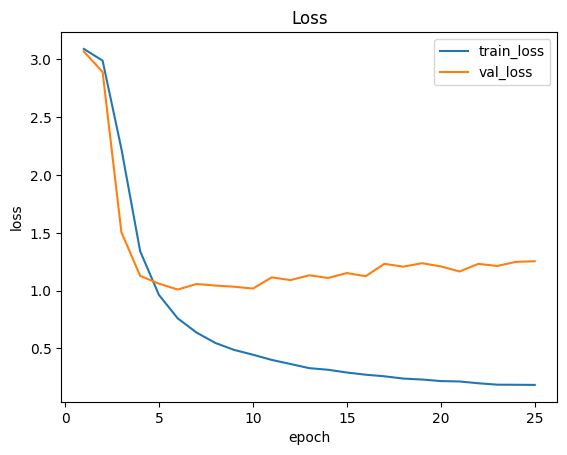

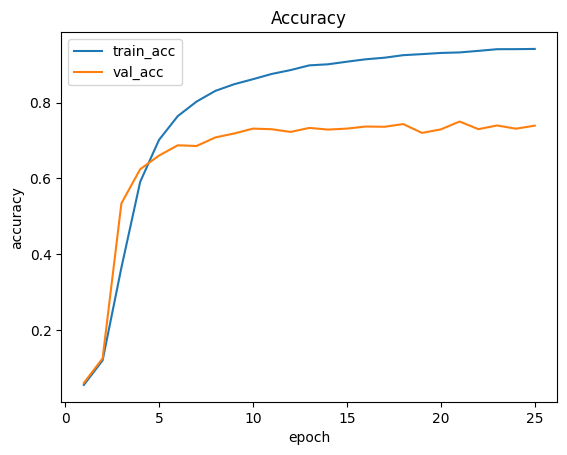

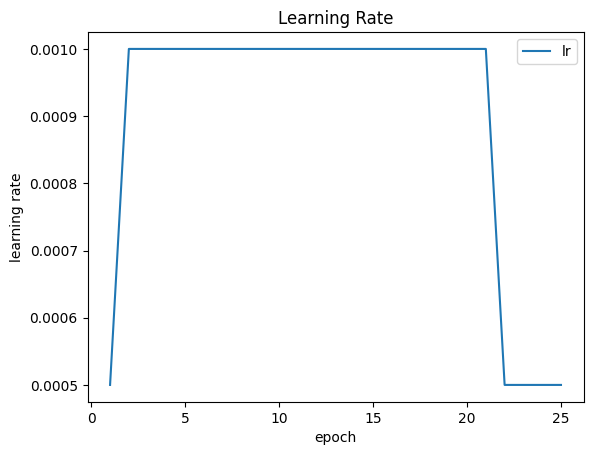

In [13]:
if not hist.empty:
    plt.figure()
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
    plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["lr"], label="lr")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("learning rate")
    plt.title("Learning Rate")
    plt.show()

## 11) Best-model evaluation

val eval: 100%|██████████| 34/34 [00:09<00:00,  3.62it/s]


Accuracy: 0.7503461005999077
Macro F1: 0.7340760055860632

Classification report:

                          precision    recall  f1-score   support

           C1_Drive_Safe     0.4582    0.8080    0.5848       224
                C2_Sleep     0.7037    0.2460    0.3645       309
              C3_Yawning     0.8736    0.8689    0.8712       183
            C4_Talk_Left     0.9849    1.0000    0.9924       261
           C5_Talk_Right     0.9694    0.4378    0.6032       217
            C6_Text_Left     0.8692    0.7793    0.8218       145
           C7_Text_Right     0.8646    0.7313    0.7924       227
              C8_Make_Up     0.6947    0.9851    0.8148       268
            C9_Look_Left     0.9726    0.8802    0.9241       242
          C10_Look_Right     0.5511    0.6783    0.6082       143
             C11_Look_Up     0.7978    1.0000    0.8875       146
           C12_Look_Down     0.4899    0.7192    0.5828       203
          C13_Smoke_Left     0.9060    0.8618    0.8833   

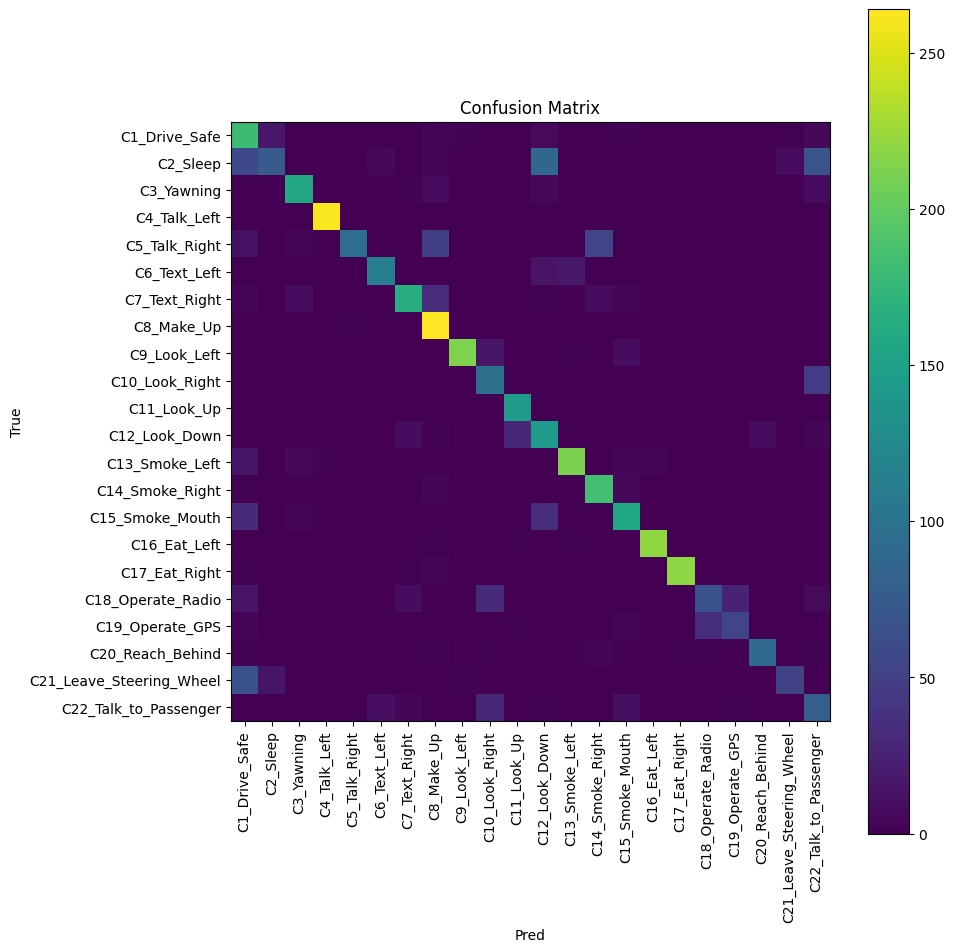

In [14]:
best_model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
in_features = best_model.classifier[-1].in_features
best_model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

state_dict = torch.load(best_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="val eval"):
        xb = xb.to(device, non_blocking=True)
        logits = best_model(xb)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=90)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

## 12) Quick inference preview

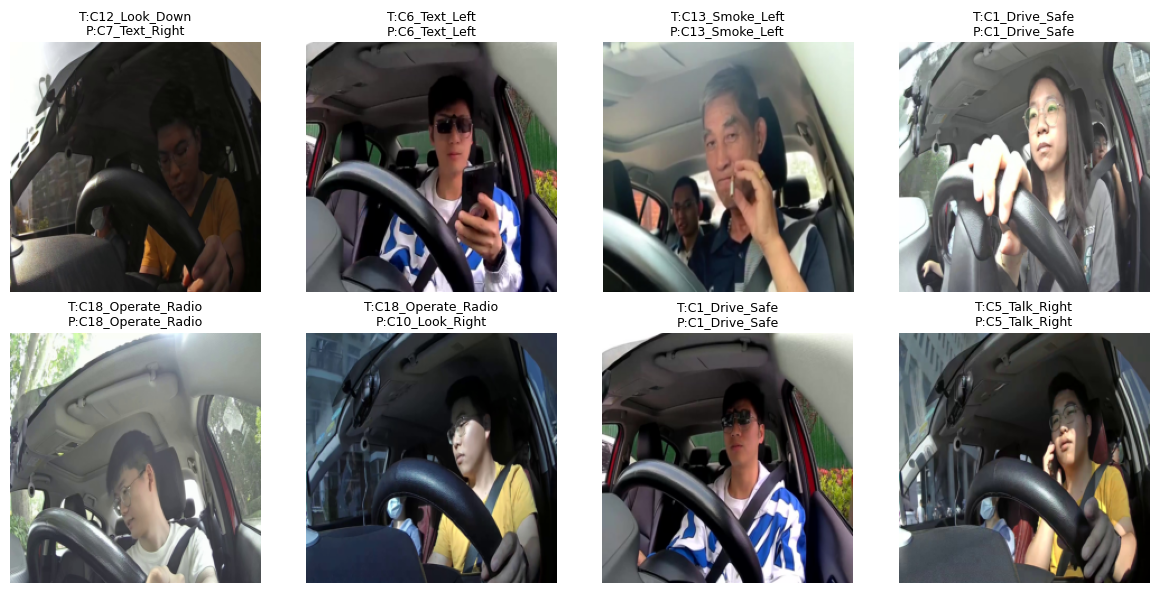

In [15]:
def denorm(x, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (x * std_t) + mean_t

best_model.eval()
sample_count = min(8, len(val_ds))
sample_idx = np.random.choice(len(val_ds), size=sample_count, replace=False)
samples = [val_ds[i] for i in sample_idx]
xb = torch.stack([s[0] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(sample_count):
    ax = plt.subplot(2, math.ceil(sample_count / 2), i + 1)
    img = denorm(samples[i][0].cpu(), mean, std).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[pred[i]]}", fontsize=9)
plt.tight_layout()
plt.show()